In [ ]:
# Helper cell for folder setup and type checking. Only run if the kernel is Sage.
# sage -n jupyter --no-browser

import os, sys
print(os.getcwd(), sys.executable)

%cd /mnt/d/Projects/m2-bezout/internship/src
from utils import styled_print

from typing import TYPE_CHECKING
if TYPE_CHECKING:
    from type_checking import *

/home/chocomint /home/chocomint/miniconda3/envs/sage/bin/python3
/mnt/d/Projects/m2-bezout/internship/src/symbolic


In [23]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

#### Compute distribution of $Y_n$

$$Y_{n} = I\left(Y_{U_n}^{(1)} + Y_{n-1-U_n}^{(2)} + 1\right) + J\max\left(Y_{U_n}^{(1)}, Y_{n-1-U_n}^{(2)}\right), \quad Y_0=Y_1=0.$$

Given that the subscripts are for independent copies. The variables $I$ and $J$ are Bernoulli with expectation $u$ and $v$ respectively such that $I+J\le 1$ and $u+v\le 1$, and they are inpependent of all $Y^{(j)}_i$. The variable $U_n$ is uniform in $\{0,\ldots,n-1\}$.

In [ ]:
def solve_for_alpha(u, v, initial_guess=0.0):
    """
    Solves the equation: alpha + 1 - 2(u + v) + v * 2^(-alpha) = 0
    """
    # Define the equation as a function of alpha
    def equation(alpha):
        return alpha + 1 - 2*(u + v) + v * (2.0 ** (-alpha))
    
    # fsolve returns an array, we extract the first element
    alpha_solution = fsolve(equation, initial_guess, xtol=1e-10)[0]
    
    # Verify the solution is close to zero (optional checking)
    tolerance = 1e-6
    if abs(equation(alpha_solution)) > tolerance:
        print("Warning: The solver may not have converged to a true root.")
        
    return alpha_solution

u = 0.5
v = 0.3

# Calculate the root
alpha = solve_for_alpha(u, v, initial_guess=1.0)
print(f"For u={u} and v={v}, alpha is approximately: {alpha:.6f}")
print(f"Verification: alpha + 1 - 2(u + v) + v * 2^(-alpha) = {alpha + 1 - 2*(u + v) + v * (2.0 ** (-alpha)):.6e}")
print(alpha - 2*u - v + 1, 2*(u+v) - 1 - alpha)

For u=0.5 and v=0.3, alpha is approximately: 0.367455
Verification: alpha + 1 - 2(u + v) + v * 2^(-alpha) = -1.110223e-16
0.06745546498928512 0.23254453501071487


In [ ]:
def compute_exact_distributions_symbolic(max_N):
    # Declare u and v as symbolic variables
    u, v = var('u v')
    
    # Initialize matrices with Sage's Symbolic Ring (SR) zeros
    pmf = [[SR(0)] * (max_N + 1) for _ in range(max_N + 1)]
    cdf = [[SR(0)] * (max_N + 1) for _ in range(max_N + 1)]
    
    # Base cases: Y_0 = 0, Y_1 = 0
    pmf[0][0] = SR(1)
    pmf[1][0] = SR(1)
    
    for i in range(2):
        for k in range(max_N + 1):
            cdf[i][k] = SR(1)

    termination_prob = 1 - u - v

    for n in range(2, max_N + 1):
        # Y_n is bounded by n - 1
        for k in range(n):
            prob_k = SR(0)
            
            # U_n is uniformly distributed over {0, ..., n-1}
            for i in range(n):
                idx1 = i
                idx2 = n - 1 - i
                
                # I: sum of independent copies + 1
                c_prob = SR(0)
                if k >= 1:
                    for j in range(k):
                        c_prob += pmf[idx1][j] * pmf[idx2][k - 1 - j]
                        
                # J: max of independent copies
                cdf1_k = cdf[idx1][k]
                cdf2_k = cdf[idx2][k]
                cdf1_k_minus_1 = cdf[idx1][k - 1] if k > 0 else SR(0)
                cdf2_k_minus_1 = cdf[idx2][k - 1] if k > 0 else SR(0)
                
                m_prob = (cdf1_k * cdf2_k) - (cdf1_k_minus_1 * cdf2_k_minus_1)
                
                prob_k += u * c_prob + v * m_prob
                
            t_prob = SR(1) if k == 0 else SR(0)
            
            # Divide by n for the uniform distribution expectation
            pmf[n][k] = ((prob_k / n) + (termination_prob * t_prob)).expand()
            
        current_cdf = SR(0)
        for k in range(max_N + 1):
            if k < n:
                current_cdf += pmf[n][k]
            cdf[n][k] = current_cdf.expand()

    expected_values = []
    for i in range(1, max_N + 1):
        expected_y = sum(k * pmf[i][k] for k in range(i))
        expected_values.append(expected_y.expand())

    return pmf, cdf, expected_values

pmf_sym, cdf_sym, ev_sym = compute_exact_distributions_symbolic(20)

In [1]:
def compute_exact_distributions_symbolic_homogenized(max_N):
    # Declare a and b as symbolic variables
    a, b = var('a b')
    
    # Initialize matrices with Sage's Symbolic Ring (SR) zeros
    pmf = [[SR(0)] * (max_N + 1) for _ in range(max_N + 1)]
    cdf = [[SR(0)] * (max_N + 1) for _ in range(max_N + 1)]
    
    # Homogenized initial conditions: Y_1 = Y_2 = 1 (Y_0 remains 0)
    pmf[0][0] = SR(1)
    pmf[1][1] = SR(1)
    pmf[2][1] = SR(1)
    
    # Update CDFs to reflect that size 1 and 2 trees evaluate to 1
    for k in range(max_N + 1):
        cdf[0][k] = SR(1)
        cdf[1][k] = SR(1) if k >= 1 else SR(0)
        cdf[2][k] = SR(1) if k >= 1 else SR(0)

    termination_prob = 1 - a - b

    for N_target in range(3, max_N + 1):
        n = N_target - 2
        
        for k in range(N_target):
            prob_k = SR(0)
            
            for u in range(1, n + 1):
                v = n + 1 - u
                
                # Standard discrete convolution for the sum of two independent variables
                c_prob = SR(0)
                for j in range(k + 1):
                    c_prob += pmf[u][j] * pmf[v][k - j]
                        
                cdf_u_k = cdf[u][k]
                cdf_v_k = cdf[v][k]
                cdf_u_k_minus_1 = cdf[u][k - 1] if k > 0 else SR(0)
                cdf_v_k_minus_1 = cdf[v][k - 1] if k > 0 else SR(0)
                
                m_prob = (cdf_u_k * cdf_v_k) - (cdf_u_k_minus_1 * cdf_v_k_minus_1)
                
                prob_k += a * c_prob + b * m_prob
                
            t_prob = SR(1) if k == 0 else SR(0)
            
            pmf[N_target][k] = ((prob_k / n) + (termination_prob * t_prob)).expand()
            
        current_cdf = SR(0)
        for k in range(max_N + 1):
            if k < N_target:
                current_cdf += pmf[N_target][k]
            cdf[N_target][k] = current_cdf.expand()

    # Calculate expected values mapping index i directly to Y_i
    expected_values = []
    for i in range(max_N + 1):
        expected_y = sum(k * pmf[i][k] for k in range(max_N + 1))
        expected_values.append(expected_y.expand())

    return pmf, cdf, expected_values



In [5]:
def compute_symbolic_conservative(max_N):
    # Only 'a' is a free variable
    a = var('a')
    b = 1 - a
    
    pmf = [[SR(0)] * (max_N + 1) for _ in range(max_N + 1)]
    cdf = [[SR(0)] * (max_N + 1) for _ in range(max_N + 1)]
    
    # Base cases strictly start at 1
    pmf[1][1] = SR(1)
    pmf[2][1] = SR(1)
    
    for k in range(max_N + 1):
        cdf[1][k] = SR(1) if k >= 1 else SR(0)
        cdf[2][k] = SR(1) if k >= 1 else SR(0)

    for N_target in range(3, max_N + 1):
        n = N_target - 2
        
        # Y_N strictly ranges from 1 to N_target - 1
        for k in range(1, N_target):
            prob_k = SR(0)
            
            for u in range(1, n + 1):
                v = n + 1 - u
                
                # Convolution: limits shifted because sub-trees >= 1
                c_prob = SR(0)
                for j in range(1, k):
                    c_prob += pmf[u][j] * pmf[v][k - j]
                        
                cdf_u_k = cdf[u][k]
                cdf_v_k = cdf[v][k]
                cdf_u_k_minus_1 = cdf[u][k - 1] 
                cdf_v_k_minus_1 = cdf[v][k - 1] 
                
                m_prob = (cdf_u_k * cdf_v_k) - (cdf_u_k_minus_1 * cdf_v_k_minus_1)
                
                prob_k += a * c_prob + b * m_prob
                
            pmf[N_target][k] = (prob_k / n).expand()
            
        current_cdf = SR(0)
        for k in range(max_N + 1):
            if k < N_target:
                current_cdf += pmf[N_target][k]
            cdf[N_target][k] = current_cdf.expand()

    # --- CORRECTED EXPECTATION LOOP ---
    expected_values = [SR(0)] * (max_N + 1)
    for i in range(1, max_N + 1):
        expected_y = sum((k * pmf[i][k] for k in range(max_N + 1)), SR(0))
        expected_values[i] = expected_y.expand()

    return pmf, cdf, expected_values



In [6]:
# Example usage
pmf_sym, cdf_sym, ev_sym = compute_symbolic_conservative(20)

In [9]:
for i in range(len(ev_sym)):
    styled_print(ev_sym[i])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# Example usage for max_N = 5
pmf_sym, cdf_sym, ev_sym = compute_exact_distributions_symbolic_homogenized(20)


In [ ]:
for i in range(len(pmf_sym)):
    val = pmf_sym[i][0].subs(a=0.5, b=0.3)
    print(val)

In [49]:
# for i in range(len(pmf_sym)):
#     styled_print(pmf_sym[i])

for i in range(len(cdf_sym)):
    styled_print(cdf_sym[i])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [62]:
for i in range(len(pmf_sym)):
    styled_print(pmf_sym[i])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [13]:
import scipy.integrate as integrate

def compute_H(p, u, v, alpha):
    """
    Computes the contraction function H(p, alpha) for a given p.
    
    Parameters:
    p (float): The Wasserstein parameter / power.
    u (float): Probability of the sum operation (I).
    v (float): Probability of the max operation (J).
    alpha (float): The scaling exponent.
    
    Returns:
    float: The evaluated value of H(p, alpha).
    """
    # 1. Define the integrand: (x^alpha + (1-x)^alpha)^p
    def integrand(x):
        return (x**alpha + (1 - x)**alpha)**p
    
    # 2. Compute the integral from 0 to 1
    # quad returns a tuple: (value_of_integral, estimate_of_absolute_error)
    integral_value, error_estimate = integrate.quad(integrand, 0, 1, epsrel=1e-12)
    
    # 3. Add the maximum term component
    max_term = (2 * v) / (alpha * p + 1)
    
    # 4. Combine for the final result
    H_value = u * integral_value + max_term
    
    return H_value


# Example parameters
u = 0.5
v = 0.3

lower = 0.3
upper = 0.

alpha = 0

print(f"Iteration | alpha | H(p=1, alpha)")

for _ in range(20):
    mid = (lower + upper) / 2
    H_mid = compute_H(1, u, v, mid)

    if H_mid < 1:
        upper = mid
    else:        
        lower = mid

    print(f"{_+1:9d} | {mid:.6f} | {H_mid:.6f}")

    alpha = mid



Iteration | alpha | H(p=1, alpha)
        1 | 0.150000 | 1.391304
        2 | 0.075000 | 1.488372
        3 | 0.037500 | 1.542169
        4 | 0.018750 | 1.570552
        5 | 0.009375 | 1.585139
        6 | 0.004687 | 1.592535
        7 | 0.002344 | 1.596259
        8 | 0.001172 | 1.598127
        9 | 0.000586 | 1.599063
       10 | 0.000293 | 1.599531
       11 | 0.000146 | 1.599766
       12 | 0.000073 | 1.599883
       13 | 0.000037 | 1.599941
       14 | 0.000018 | 1.599971
       15 | 0.000009 | 1.599985
       16 | 0.000005 | 1.599993
       17 | 0.000002 | 1.599996
       18 | 0.000001 | 1.599998
       19 | 0.000001 | 1.599999
       20 | 0.000000 | 1.600000


In [91]:
import numpy as np
from scipy.optimize import brentq

def get_scaling_factor(alpha, u, v, iterations=50, pop_size=10000):
    """
    Finds the mean scaling factor for a fixed alpha.
    If factor > 1, the system grows (alpha is too small).
    If factor < 1, the system shrinks (alpha is too large).
    """
    # Initialize population with mean 1 (Exponential is a good starting guess)
    X = np.random.exponential(1.0, pop_size)
    
    for _ in range(iterations):
        # 1. Generate random variables
        U = np.random.uniform(0, 1, pop_size)
        # Shuffle X to get independent copies X1, X2
        X1 = X.copy()
        np.random.shuffle(X)
        X2 = X
        
        # 2. Indicators I and J (mutually exclusive)
        rand_val = np.random.uniform(0, 1, pop_size)
        I = (rand_val < u)
        J = (rand_val >= u) & (rand_val < u + v)
        
        # 3. Apply weights
        W1 = U**alpha
        W2 = (1 - U)**alpha
        
        # 4. Compute components
        sum_comp = W1 * X1 + W2 * X2
        max_comp = np.maximum(W1 * X1, W2 * X2)
        
        # 5. New population
        # (Points where I+J=0 become 0 in this simplified model)
        X_new = np.where(I, sum_comp, np.where(J, max_comp, 0))
        
        # Calculate mean to check drift
        current_mean = np.mean(X_new)
        
        # Normalize to prevent the population from vanishing or exploding
        if current_mean > 0:
            X = X_new / current_mean
        else:
            return 0.0 # System collapsed
            
    return current_mean

def find_true_alpha(u, v):
    # Deterministic Lower Bound as start
    # 2u + 2v(1 - 2^-(a+1)) = a+1
    # For a rough guess, use alpha = 2(u+v)-1
    low = 2.0 * u + v - 1.0
    high = 2.0 * (u + v) - 1.0
    
    print(f"Searching for alpha in range [{low:.3f}, {high:.3f}]...")
    
    def objective(a):
        factor = get_scaling_factor(a, u, v)
        return factor - 1.0

    true_alpha = brentq(objective, low, high, xtol=1e-10)
    return true_alpha

# --- Execution ---
u_param = 0.5
v_param = 0.3

# Calculate deterministic lower bound for comparison
det_lb = brentq(lambda a: (2*u_param + 2*v_param*(1 - 0.5**(a+1)))/(a+1) - 1, 0, 2)

true_a = find_true_alpha(u_param, v_param)

print("-" * 30)
print(f"Results for u={u_param}, v={v_param}:")
print(f"Deterministic Lower Bound alpha: {det_lb:.6f}")
print(f"True Stochastic alpha:          {true_a:.6f}")
print(f"Difference (Stochastic Push):   {true_a - det_lb:.6f}")

Searching for alpha in range [0.300, 0.600]...
------------------------------
Results for u=0.5, v=0.3:
Deterministic Lower Bound alpha: 0.367455
True Stochastic alpha:          0.476540
Difference (Stochastic Push):   0.109084


Simulating for u=0.5, v=0.3...
Lower Bound: 0.3675 | Upper Bound: 0.6000
Iteration 0: Mean=0.9866 < 1.0, decreasing alpha.
Iteration 1: Mean=0.9969 < 1.0, decreasing alpha.
Iteration 2: Mean=0.9970 < 1.0, decreasing alpha.
Iteration 3: Mean=0.9991 < 1.0, decreasing alpha.
Iteration 4: Mean=0.9962 < 1.0, decreasing alpha.
Iteration 5: Mean=0.9945 < 1.0, decreasing alpha.
Iteration 6: Mean=0.9947 < 1.0, decreasing alpha.
Iteration 7: Mean=0.9979 < 1.0, decreasing alpha.
Iteration 8: Mean=0.9970 < 1.0, decreasing alpha.
Iteration 9: Mean=0.9952 < 1.0, decreasing alpha.
Iteration 10: Mean=0.9973 < 1.0, decreasing alpha.
Iteration 11: Mean=0.9966 < 1.0, decreasing alpha.
Iteration 12: Mean=0.9936 < 1.0, decreasing alpha.
Iteration 13: Mean=0.9945 < 1.0, decreasing alpha.
Iteration 14: Mean=0.9971 < 1.0, decreasing alpha.
Iteration 15: Mean=0.9945 < 1.0, decreasing alpha.
Iteration 16: Mean=0.9992 < 1.0, decreasing alpha.
Iteration 17: Mean=0.9978 < 1.0, decreasing alpha.
Iteration 18: Mean=

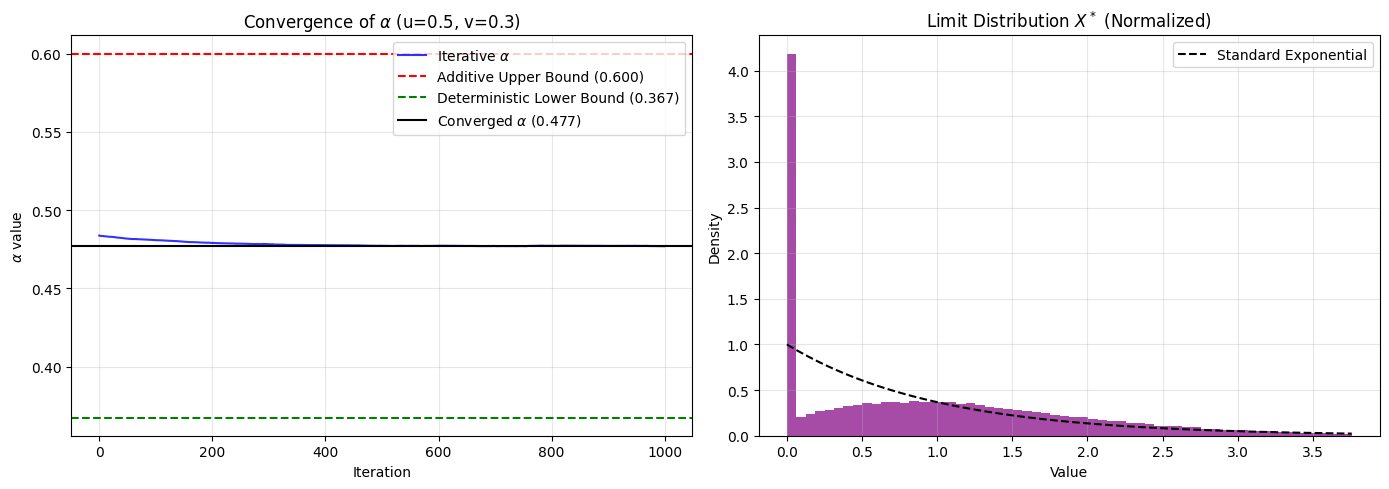

In [120]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

def compute_bounds(u, v):
    """Calculates the theoretical upper and lower bounds for alpha."""
    upper_bound = 2 * (u + v) - 1
    
    # Solve the deterministic lower bound equation: 2u + 2v(1 - 2^-(a+1)) = a+1
    def det_eq(a):
        return (2 * u + 2 * v * (1 - 0.5**(a + 1))) / (a + 1) - 1.0
    
    try:
        lower_bound = brentq(det_eq, 0.001, 2.0)
    except ValueError:
        lower_bound = 0.0 # Fallback if no root is found
        
    return lower_bound, upper_bound

def find_stochastic_alpha(u, v, num_particles=50000, iterations=1000, learning_rate=0.05):
    """
    Co-evolves the population and alpha to find the mean-preserving fixed point.
    """
    lower_bound, upper_bound = compute_bounds(u, v)
    
    # 1. Initialize population with mean 1
    # We use an Exponential distribution as a good starting guess for the tail shape
    X = np.random.exponential(1.0, num_particles)
    
    # 2. Initialize alpha in the middle of our theoretical bounds
    current_alpha = (lower_bound + upper_bound) / 2.0
    
    alpha_history = []
    
    print(f"Simulating for u={u}, v={v}...")
    print(f"Lower Bound: {lower_bound:.4f} | Upper Bound: {upper_bound:.4f}")
    
    for i in range(iterations):
        alpha_history.append(current_alpha)
        
        # Draw uniform variables for weights
        U = np.random.uniform(0, 1, num_particles)
        
        # Shuffle to get two independent draws from the current distribution
        X1 = X.copy()
        np.random.shuffle(X)
        X2 = X
        
        # Calculate weights
        W1 = U ** current_alpha
        W2 = (1.0 - U) ** current_alpha
        
        # Operation selector
        P = np.random.uniform(0, 1, num_particles)
        
        # Create masks for the operations
        mask_sum = P < u
        mask_max = (P >= u) & (P < u + v)
        # mask_zero is implicitly the remaining probability
        
        # Apply the operator
        X_new = np.zeros(num_particles)
        X_new[mask_sum] = W1[mask_sum] * X1[mask_sum] + W2[mask_sum] * X2[mask_sum]
        X_new[mask_max] = np.maximum(W1[mask_max] * X1[mask_max], W2[mask_max] * X2[mask_max])
        
        # Measure the drift
        current_mean = np.mean(X_new)
        
        # Update alpha: 
        # If mean > 1 (growing), we need smaller weights -> increase alpha
        # If mean < 1 (shrinking), we need larger weights -> decrease alpha
        if current_mean > 1.0:
            print(f"Iteration {i}: Mean={current_mean:.4f} > 1.0, increasing alpha.")
        else:
            print(f"Iteration {i}: Mean={current_mean:.4f} < 1.0, decreasing alpha.")
        current_alpha = current_alpha + learning_rate * (current_mean - 1.0)
        
        # Ensure alpha doesn't collapse below 0
        current_alpha = max(0.001, current_alpha)
        
        # Normalize the population back to mean=1 for the next iteration
        if current_mean > 0:
            X = X_new / current_mean
        else:
            print("Population collapsed to 0.")
            break
            
    final_alpha = np.mean(alpha_history[-100:]) # Average the last 100 steps to smooth noise
    print(f"Converged Stochastic Alpha: {final_alpha:.4f}")
    
    return alpha_history, final_alpha, lower_bound, upper_bound, X


u_val = 0.5
v_val = 0.3

history, true_alpha, lb, ub, final_population = find_stochastic_alpha(
    u=u_val, 
    v=v_val, 
    num_particles=100000, # Large population reduces Monte Carlo noise
    iterations=1000,       # Number of feedback loops
    learning_rate=0.01     # How aggressively alpha corrects itself
)

# --- Plotting the Results ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Convergence of Alpha
ax1.plot(history, label="Iterative $\\alpha$", color='blue', alpha=0.8)
ax1.axhline(ub, color='red', linestyle='--', label=f"Additive Upper Bound ({ub:.3f})")
ax1.axhline(lb, color='green', linestyle='--', label=f"Deterministic Lower Bound ({lb:.3f})")
ax1.axhline(true_alpha, color='black', linestyle='-', label=f"Converged $\\alpha$ ({true_alpha:.3f})")

ax1.set_title(f"Convergence of $\\alpha$ (u={u_val}, v={v_val})")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("$\\alpha$ value")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Tail shape of the Limit Distribution X*
# We clip the top 1% of outliers for a cleaner histogram
clip_val = np.percentile(final_population, 99)
filtered_pop = final_population[final_population < clip_val]

ax2.hist(filtered_pop, bins=60, density=True, color='purple', alpha=0.7)

# Overlay standard exponential for visual comparison
x_axis = np.linspace(0, clip_val, 100)
ax2.plot(x_axis, np.exp(-x_axis), 'k--', label="Standard Exponential")

ax2.set_title("Limit Distribution $X^*$ (Normalized)")
ax2.set_xlabel("Value")
ax2.set_ylabel("Density")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [67]:
compute_H(0.99, u, v, alpha)

0.9995548665280476

In [ ]:
def compute_exact_distributions(max_N, a, b):
    pmf = [[0.0] * (max_N + 1) for _ in range(max_N + 1)]
    cdf = [[0.0] * (max_N + 1) for _ in range(max_N + 1)]
    
    pmf[0][0] = 1.0
    pmf[1][0] = 1.0
    pmf[2][0] = 1.0
    
    for i in range(3):
        for k in range(max_N + 1):
            cdf[i][k] = 1.0

    termination_prob = 1.0 - a - b

    for N_target in range(3, max_N + 1):
        n = N_target - 2
        
        for k in range(N_target):
            prob_k = 0.0
            
            for u in range(1, n + 1):
                v = n + 1 - u
                
                c_prob = 0.0
                if k >= 1:
                    for j in range(k):
                        c_prob += pmf[u][j] * pmf[v][k - 1 - j]
                        
                cdf_u_k = cdf[u][k]
                cdf_v_k = cdf[v][k]
                cdf_u_k_minus_1 = cdf[u][k - 1] if k > 0 else 0.0
                cdf_v_k_minus_1 = cdf[v][k - 1] if k > 0 else 0.0
                
                m_prob = (cdf_u_k * cdf_v_k) - (cdf_u_k_minus_1 * cdf_v_k_minus_1)
                
                # Accumulate the conditional probabilities based on the split
                prob_k += a * c_prob + b * m_prob
                
            # Divide by n to account for the uniform split, then add the independent termination term
            t_prob = 1.0 if k == 0 else 0.0
            pmf[N_target][k] = (prob_k / n) + (termination_prob * t_prob)
            
        current_cdf = 0.0
        for k in range(max_N + 1):
            if k < N_target:
                current_cdf += pmf[N_target][k]
            cdf[N_target][k] = current_cdf

    expected_values = []
    for i in range(1, max_N + 1):
        expected_y = sum(k * pmf[i][k] for k in range(i))
        expected_values.append(expected_y)

    return pmf, cdf, expected_values

In [24]:
def compute_exact_distributions_optimized(max_N, a, b):
    
    pmfs = [np.array([1.0]), np.array([1.0]), np.array([1.0])]
    cdfs = [np.array([1.0]), np.array([1.0]), np.array([1.0])]
    
    termination_prob = 1.0 - a - b

    for N_target in range(3, max_N + 1):
        if N_target % 10 == 0:
            print(f"Computing upto N={N_target}...")

        n = N_target - 2
        
        # Y_N <= N-1
        current_pmf = np.zeros(N_target)
        
        # Use symmetry: evaluate up to (n+1)//2 and double the weights, except for the middle case when n is odd
        for u in range(1, ((n + 1) // 2) + 1):
            v = n + 1 - u
            weight = 2.0 if u != v else 1.0
            
            # --- 1. Concatenation Term ---
            # Compute discrete convolution of PMFs
            conv_pmf = np.convolve(pmfs[u], pmfs[v])
            
            # Shift by 1 to account for the "+ 1" in the formula
            concat_pmf = np.zeros(len(conv_pmf) + 1)
            concat_pmf[1:] = conv_pmf
            
            length_c = min(len(concat_pmf), N_target)
            current_pmf[:length_c] += weight * a * concat_pmf[:length_c]
            
            # --- 2. Alternation Term ---
            # Max of two variables: CDF_max = CDF_u * CDF_v
            len_u = len(cdfs[u])
            len_v = len(cdfs[v])
            max_len = max(len_u, len_v)
            
            cdf_u_ext = np.ones(max_len)
            cdf_u_ext[:len_u] = cdfs[u]
            
            cdf_v_ext = np.ones(max_len)
            cdf_v_ext[:len_v] = cdfs[v]
            
            cdf_max = cdf_u_ext * cdf_v_ext
            
            # PMF is the backward difference of the CDF
            pmf_max = np.zeros(max_len)
            pmf_max[0] = cdf_max[0]
            pmf_max[1:] = cdf_max[1:] - cdf_max[:-1]
            
            length_m = min(len(pmf_max), N_target)
            current_pmf[:length_m] += weight * b * pmf_max[:length_m]
            
        # Average over the uniform choice of U_n
        current_pmf /= n
        
        # --- 3. Termination Term ---
        current_pmf[0] += termination_prob
        
        # Correct minor floating-point inaccuracies from repeated array operations
        current_pmf = np.maximum(current_pmf, 0)
        current_pmf /= np.sum(current_pmf)
        
        pmfs.append(current_pmf)
        cdfs.append(np.cumsum(current_pmf))
    
    return pmfs

Computing upto N=10...
Computing upto N=20...
Computing upto N=30...
Computing upto N=40...
Computing upto N=50...
Computing upto N=60...
Computing upto N=70...
Computing upto N=80...
Computing upto N=90...
Computing upto N=100...
Computing upto N=110...
Computing upto N=120...
Computing upto N=130...
Computing upto N=140...
Computing upto N=150...
Computing upto N=160...
Computing upto N=170...
Computing upto N=180...
Computing upto N=190...
Computing upto N=200...
Computing upto N=210...
Computing upto N=220...
Computing upto N=230...
Computing upto N=240...
Computing upto N=250...
Computing upto N=260...
Computing upto N=270...
Computing upto N=280...
Computing upto N=290...
Computing upto N=300...
Computing upto N=310...
Computing upto N=320...
Computing upto N=330...
Computing upto N=340...
Computing upto N=350...
Computing upto N=360...
Computing upto N=370...
Computing upto N=380...
Computing upto N=390...
Computing upto N=400...
Computing upto N=410...
Computing upto N=420...
C

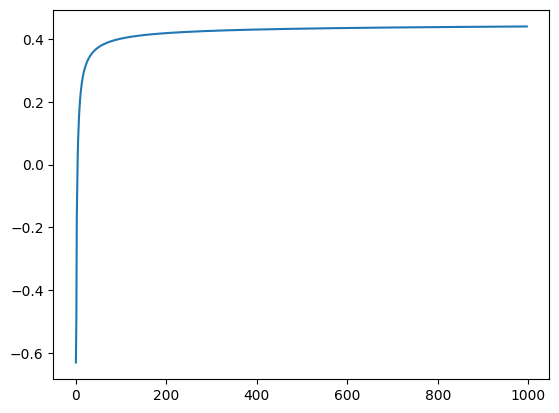

In [25]:
MAX_SIZE = 1000

a=0.5
b=0.3

pmfs = compute_exact_distributions_optimized(MAX_SIZE, a, b)
expectations = [np.sum(np.arange(len(pmf)) * pmf) for pmf in pmfs]
# print(expectations)
normalized = np.log(expectations[3:]) / np.log(np.arange(3, MAX_SIZE+1))

plt.plot(normalized, label=f'Log-Log Normalized Expectations (a={a}, b={b})')
print(normalized[-1])

# _,alpha,_,_,_ = find_stochastic_alpha(a,b)
# print(f"Estimated alpha: {alpha:.6f}")
# normalized = np.concatenate([expectations[:1],
#                              expectations[1:] / np.arange(1, MAX_SIZE+1)**alpha])
# plt.plot(normalized, label=f'Normalized Expectations (a={a}, b={b})')
# plt.xlabel('$N$')
# plt.ylabel('$E[Y_N] / N^\\alpha$')

In [70]:
pmfs[11]

array([0.26680286, 0.24367386, 0.2468037 , 0.16723457, 0.06845238,
       0.00703263, 0.        , 0.        , 0.        , 0.        ,
       0.        ])

Text(0, 0.5, '$E[Y_N] / N^\\alpha$')

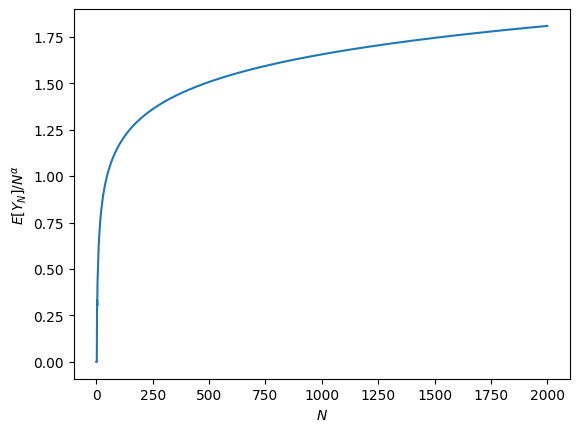

In [152]:
alpha = normalized[-1]
ratios = np.concatenate([expectations[:1],
                             expectations[1:] / np.arange(1, MAX_SIZE+1)**0.3674554649892853])
plt.plot(ratios, label=f'Normalized Expectations (a={a}, b={b})')
plt.xlabel('$N$')
plt.ylabel('$E[Y_N] / N^\\alpha$')

In [113]:
pmfs[20]

array([0.23888922, 0.13664676, 0.17027877, 0.16278189, 0.12996266,
       0.0882157 , 0.04843366, 0.01952166, 0.00481352, 0.00045615,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

Solve $\alpha + 1 = a + b(1-2^{-\alpha+1})$

In [57]:
def solve_alpha(a, b, initial_guess=0.0, tolerance=1e-10, max_iterations=10000):
    """
    Solves alpha + 1 = a + b(1 - 2^{-alpha+1}) using fixed-point iteration.
    """
    alpha = initial_guess
    
    for i in range(max_iterations):
        # The iteration function: f(alpha) = a + b(1 - 2^-alpha) - 1
        next_alpha = a + b * (1 - 2**(-alpha)) - 1
        
        # Check for convergence
        if abs(next_alpha - alpha) < tolerance:
            return next_alpha
        
        alpha = next_alpha
        
    raise RuntimeError("Convergence not reached within the maximum number of iterations.")

In [81]:
import matplotlib.pyplot as plt

MAX_SIZE = 3000
u = 0.5
v = 0.3

pmf4, cdf4, expectations4 = compute_exact_distributions_optimized(MAX_SIZE, u, v)

alpha = 0.47

normalized = [expectations4[i] / (i+1)**alpha for i in range( MAX_SIZE)]

plt.figure(figsize=(8,5))
plt.plot(normalized, label='Normalized $E[Y_N]$ (u=0.5,v=0.3)')
plt.xlabel('$N$')

Computing upto N=10...
Computing upto N=20...
Computing upto N=30...
Computing upto N=40...
Computing upto N=50...
Computing upto N=60...
Computing upto N=70...
Computing upto N=80...
Computing upto N=90...
Computing upto N=100...
Computing upto N=110...
Computing upto N=120...
Computing upto N=130...
Computing upto N=140...
Computing upto N=150...
Computing upto N=160...
Computing upto N=170...
Computing upto N=180...
Computing upto N=190...
Computing upto N=200...
Computing upto N=210...
Computing upto N=220...
Computing upto N=230...
Computing upto N=240...
Computing upto N=250...
Computing upto N=260...
Computing upto N=270...
Computing upto N=280...
Computing upto N=290...
Computing upto N=300...
Computing upto N=310...
Computing upto N=320...
Computing upto N=330...
Computing upto N=340...
Computing upto N=350...
Computing upto N=360...
Computing upto N=370...
Computing upto N=380...
Computing upto N=390...
Computing upto N=400...
Computing upto N=410...
Computing upto N=420...
C

ValueError: too many values to unpack (expected 3)

Text(0.5, 0, '$N$')

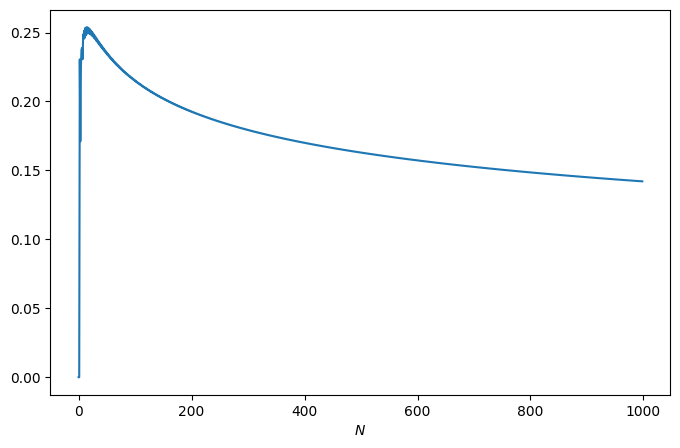

In [60]:
import matplotlib.pyplot as plt

MAX_SIZE = 1000
u = 0.5
v = 0.3

pmf4, cdf4, expectations4 = compute_exact_distributions_optimized(MAX_SIZE, u, v)

alpha = solve_alpha(2*u+2*v, v/2)
test_alpha = alpha+0.05

normalized = [expectations4[i] / i**test_alpha for i in range(1, MAX_SIZE)]

plt.figure(figsize=(8,5))
plt.plot(normalized, label='Normalized $E[Y_N]$ (u=0.5,v=0.3)')
plt.xlabel('$N$')

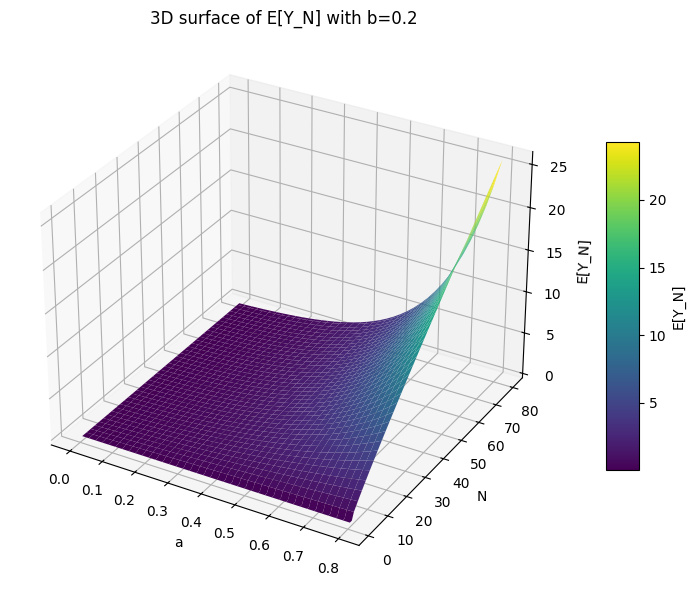

In [11]:
# 3D surface: fix b and vary a and n
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Parameters -- adjust as needed
b_fixed = 0.2
a_vals = np.linspace(0.0, 1.0 - b_fixed - 1e-8, 40)
N_max_3d = 80

# Compute expectations for each 'a' on the grid (this may be slow for large N_max_3d or many a_vals)
Z = np.zeros((len(a_vals), N_max_3d))
for i, a_val in enumerate(a_vals):
    _, _, expectations = compute_exact_distributions(N_max_3d, float(a_val), float(b_fixed))
    Z[i, :] = expectations[:N_max_3d]

# Prepare mesh for plotting: meshgrid with shape (N_max_3d, len(a_vals))
N_seq = np.arange(1, N_max_3d + 1)
A_mesh, N_mesh = np.meshgrid(a_vals, N_seq)
Z_plot = Z.T

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(A_mesh, N_mesh, Z_plot, cmap='viridis', edgecolor='none')
ax.set_xlabel('a')
ax.set_ylabel('N')
ax.set_zlabel('E[Y_N]')
ax.set_title(f'3D surface of E[Y_N] with b={b_fixed}')
fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10, label='E[Y_N]')
plt.tight_layout()
plt.show()

Computing heatmap grid: 50 a-values × N_max=200


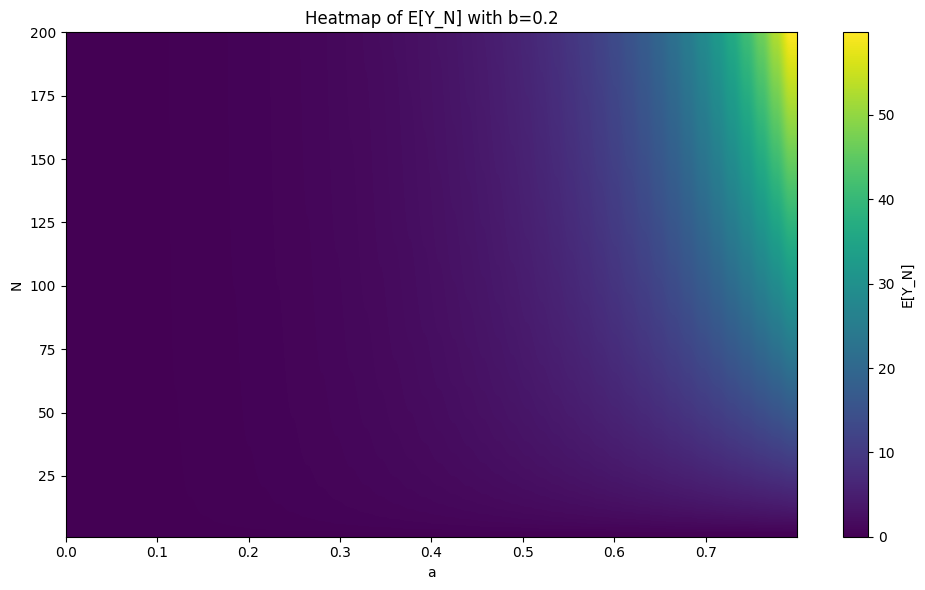

In [13]:
# Heatmap: fix b and vary a and n (moderate resolution by default)
import numpy as np
import matplotlib.pyplot as plt

# Parameters (tune these if you need more resolution)
b_fixed = 0.2
a_vals = np.linspace(0.0, 1.0 - b_fixed - 1e-8, 50)
N_max_heatmap = 200

print(f'Computing heatmap grid: {len(a_vals)} a-values × N_max={N_max_heatmap}')
# Compute expectations grid: Z[n-1, i] = E[Y_n] for a = a_vals[i]
Z = np.zeros((N_max_heatmap, len(a_vals)))
for i, a_val in enumerate(a_vals):
    _, _, expectations = compute_exact_distributions(N_max_heatmap, float(a_val), float(b_fixed))
    Z[:, i] = expectations[:N_max_heatmap]

# Plot heatmap with axis: a (x), N (y)
plt.figure(figsize=(10,6))
im = plt.imshow(Z, aspect='auto', origin='lower', extent=[a_vals[0], a_vals[-1], 1, N_max_heatmap], cmap='viridis')
plt.colorbar(im, label='E[Y_N]')
plt.xlabel('a')
plt.ylabel('N')
plt.title(f'Heatmap of E[Y_N] with b={b_fixed}')
plt.tight_layout()
plt.show()

#### Experiment with the sequence containing a difference 

$$y_{n+2} = \dfrac{a}{n}\sum_{i=1}^n y_n + \dfrac{b}{n}\sum_{i=1}^n |y_{n+1-i} - y_i| + c.$$

We want to see when $a>1$, $\lim \dfrac{y_n}{n^{a-1}}\to\infty$.
Let $P_k = \sum_{i=1}^k y_k$, we have
$$y_{n+2} = \dfrac{a}{n} P_n + \dfrac{2b}{n}\left|P_{\lfloor n/2\rfloor} + P_{n-\lfloor n/2\rfloor} - P_n\right| + c.$$
That gives an optimized implementation.

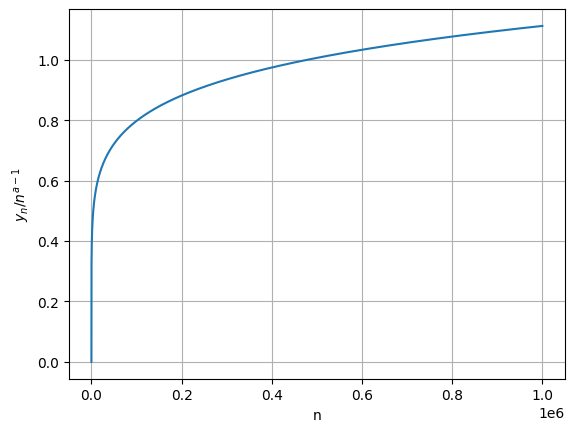

In [67]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000000
a = 1.5
b = 0.2
c = 0.1

Y = np.zeros(N)
Y[0] = Y[1] = 0
P = np.zeros(N + 1) 

for n in range(2, N):
    m = n // 2
    
    S_n = 2.0 * abs(P[m] + P[n - m] - P[n])
    y = (a / n) * P[n] + (b / n) * S_n + c
    Y[n] = y
    P[n + 1] = P[n] + y

n_vals = np.arange(1, N)
normalized = Y[1:] / np.power(n_vals, a-1)

plt.plot(n_vals, normalized) 
plt.xlabel('n')
plt.ylabel(r'$y_n / n^{a-1}$')
plt.grid(True)
plt.show()

#### Experiment with 

$$nx_{n+2} - (n-1)x_{n+1} = (a+b)x_n - bx_{\lfloor n/2\rfloor} + c.$$

##### Check asymptotic

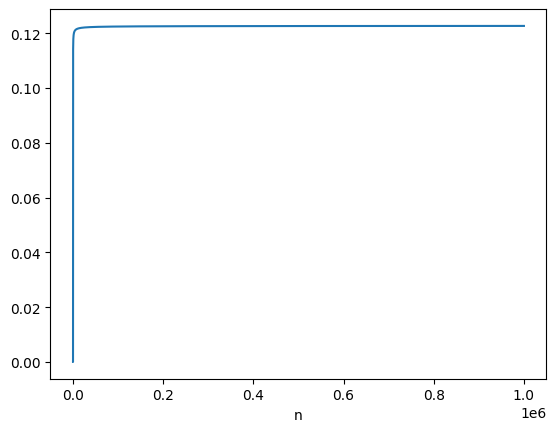

In [68]:
a = 1.5
b = 0.2
c = 0.1

alpha = solve_alpha(a, b)

N = 1000000

X = np.zeros(N+1)

for n in range(3, N+1):
    xn = ((n-3) * X[n-1] + (a+b)* X[n-2] - b*X[(n+2)//2] + c)/(n-2)
    X[n] = xn

normalized = X[1:] / np.power(np.arange(1, N+1), alpha)

plt.plot(normalized)
plt.xlabel('n')
plt.show()

##### Check concentration

[0.00017006 0.00016995 0.00016984 0.00016972 0.00016961]


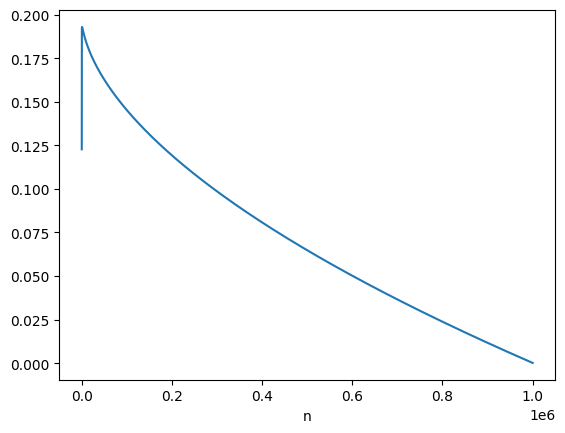

In [56]:
a = 1.5
b = 0.2
c = 0.1

alpha = solve_alpha(a, b)

N = 1000000

X = np.zeros(N+1)

for n in range(3, N+1):
    xn = ((n-3) * X[n-1] + (a+b)* X[n-2] - b*X[(n+2)//2] + c)/(n-2)
    X[n] = xn

D = X[-1]/(N-1)**alpha

concentrations = np.power(np.arange(1, N+1), alpha) * D - X[1:]

print(concentrations[-5:])

plt.plot(concentrations)
plt.xlabel('n')
plt.show()

##### Check monotonicity

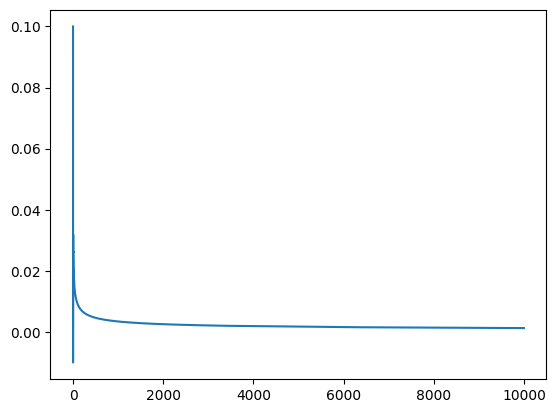

In [7]:
import numpy as np
from matplotlib import pyplot as plt

a = 1.5
b = 0.2
c = 0.1

N = 10000

X = np.zeros(N+1)

for n in range(3, N+1):
    xn = ((n-3) * X[n-1] + (a+b)* X[n-2] - b*X[(n+2)//2] + c)/(n-2)
    X[n] = xn

diffs = X[3:] - X[2:-1]

plt.plot(diffs)
# plt.plot(X[1:])

##### Check if the true $\alpha$ is closer to the lower or upper bound

Running simulation with u=0.4, v=0.4, alpha=0.45


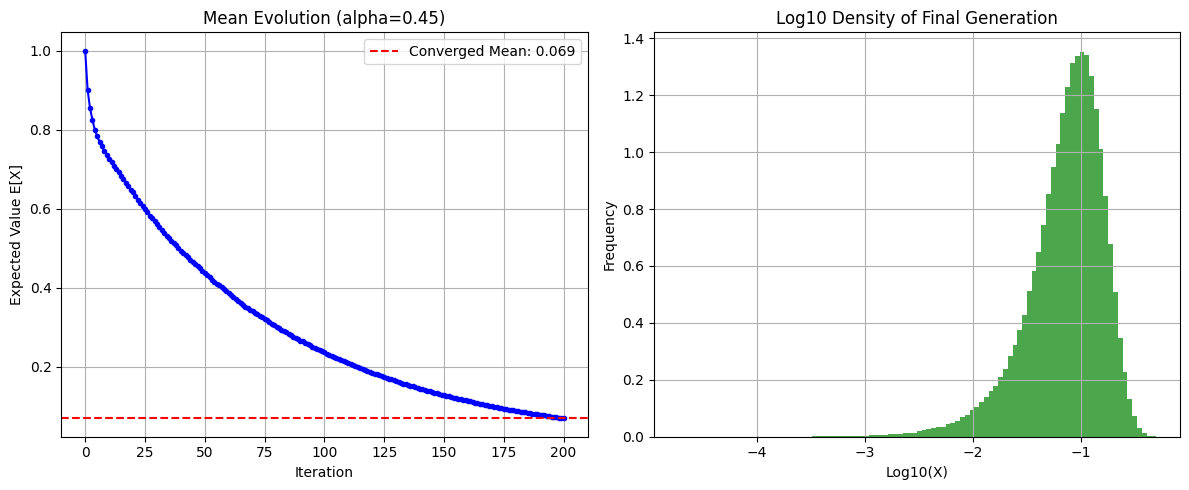

In [76]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_rde(u, v, alpha, num_particles=200000, num_iterations=50, initial_mean=1.0):
    """
    Simulates the Recursive Distributional Equation:
    X = I*(U^alpha * X1 + (1-U)^alpha * X2) + J*max(U^alpha * X1, (1-U)^alpha * X2)
    """
    if u + v > 1.0:
        raise ValueError("The sum of probabilities u and v must be <= 1")

    # Initialize the population as a Dirac delta (constant) at initial_mean
    X = np.full(num_particles, initial_mean, dtype=np.float64)

    mean_history = [np.mean(X)]

    for i in range(num_iterations):
        # Sample X1 and X2 independently from the current population
        X1 = np.random.choice(X, size=num_particles, replace=True)
        X2 = np.random.choice(X, size=num_particles, replace=True)

        # Sample U uniformly
        U = np.random.uniform(0, 1, size=num_particles)

        # Precompute the scaled terms
        term1 = (U**alpha) * X1
        term2 = ((1 - U)**alpha) * X2

        # Calculate sum and max components
        sum_component = term1 + term2
        max_component = np.maximum(term1, term2)

        # Sample the Bernoulli indicators I and J
        # Generate a uniform R to split into three mutually exclusive states:
        # R < u              -> I=1, J=0
        # u <= R < u+v       -> I=0, J=1
        # R >= u+v           -> I=0, J=0
        R = np.random.uniform(0, 1, size=num_particles)
        I = (R < u).astype(np.float64)
        J = ((R >= u) & (R < u + v)).astype(np.float64)

        # Compute the new generation
        X = I * sum_component + J * max_component

        # Track the population mean
        mean_history.append(np.mean(X))

    return X, mean_history

# --- Experiment Setup ---
# Let's test the "Goldilocks" band we discussed where the mean converges
# even though the simple L1 contraction bound fails.

u = 0.4
v = 0.4

# The simple contraction floor is 2(u+v) - 1 = 0.6
# The absolute mathematical floor is roughly 2(u+v) - 1 - v(2^-alpha)
# Let's pick an alpha strictly between these bounds:
alpha = 0.45 

print(f"Running simulation with u={u}, v={v}, alpha={alpha}")
final_population, means = simulate_rde(u, v, alpha, num_particles=300000, num_iterations=200)

# --- Plotting the Results ---
plt.figure(figsize=(12, 5))

# Plot 1: The Evolution of the Mean
plt.subplot(1, 2, 1)
plt.plot(means, marker='o', markersize=3, color='blue')
plt.axhline(y=means[-1], color='red', linestyle='--', label=f'Converged Mean: {means[-1]:.3f}')
plt.title(f"Mean Evolution (alpha={alpha})")
plt.xlabel("Iteration")
plt.ylabel("Expected Value E[X]")
plt.legend()
plt.grid(True)

# Plot 2: The Empirical Density of the Final Distribution (Log Scale)
# We use a log scale because these distributions often develop heavy tails
plt.subplot(1, 2, 2)
# Filter out exact zeros to avoid log(0) errors in the histogram
non_zero_X = final_population[final_population > 0]
plt.hist(np.log10(non_zero_X + 1e-9), bins=100, density=True, color='green', alpha=0.7)
plt.title("Log10 Density of Final Generation")
plt.xlabel("Log10(X)")
plt.ylabel("Frequency")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def find_alpha_star(u, v, low_alpha, high_alpha, tolerance=1e-10, max_steps=15):
    """
    Uses a robust bisection search to find the root of lambda(alpha) - 1 = 0.
    """
    print(f"Searching for alpha* for u={u}, v={v}")
    print(f"{'Step':<5} | {'Alpha Estimate':<15} | {'Lambda(alpha)':<15}")
    print("-" * 40)
    
    for step in range(max_steps):
        mid_alpha = (low_alpha + high_alpha) / 2.0
        
        # Estimate the growth rate for this alpha
        current_lambda, X = estimate_lambda(mid_alpha, u, v)
        
        print(f"{step+1:<5} | {mid_alpha:<15.5f} | {current_lambda:<15.5f}")
        
        # Check for convergence
        if abs(current_lambda - 1.0) < tolerance:
            print("-" * 40)
            print(f"Converged! alpha* ≈ {mid_alpha:.5f}")
            return mid_alpha, X
            
        # Update bisection bounds
        # Because lambda is strictly decreasing:
        # If lambda > 1, alpha is too small.
        if current_lambda > 1.0:
            low_alpha = mid_alpha
        # If lambda < 1, alpha is too big.
        else:
            high_alpha = mid_alpha
            
    print("-" * 40)
    print(f"Reached max steps. Best estimate for alpha* ≈ {mid_alpha:.5f}")
    return mid_alpha, X

u_val = 0.5
v_val = 0.3

floor = 2 * u_val + v_val - 1.0

# Add a small buffer to the floor to avoid massive variances near the boundary
search_lower_bound = max(0.01, floor + 0.05) 
search_upper_bound = 2 * (u_val + v_val) - 1.0 

alpha_star, final_distribution = find_alpha_star(u_val, v_val, search_lower_bound, search_upper_bound)
print(final_distribution[:10])

Searching for alpha* for u=0.5, v=0.3
Step  | Alpha Estimate  | Lambda(alpha)  
----------------------------------------
1     | 0.47500         | 1.06064        
2     | 0.53750         | 0.30591        
3     | 0.50625         | 0.55214        
4     | 0.49063         | 0.75472        
5     | 0.48281         | 0.89620        
6     | 0.47891         | 0.97089        
7     | 0.47695         | 1.02532        
8     | 0.47793         | 0.99932        
9     | 0.47744         | 1.01507        
10    | 0.47769         | 1.00222        
11    | 0.47781         | 1.00080        
12    | 0.47787         | 0.99106        
13    | 0.47784         | 1.00154        
14    | 0.47785         | 0.99237        
15    | 0.47785         | 0.98844        
----------------------------------------
Reached max steps. Best estimate for alpha* ≈ 0.47785
[1.22262593 0.         0.65196838 0.75160328 0.72960905 1.74964375
 0.10263813 1.27334348 0.81965382 0.        ]


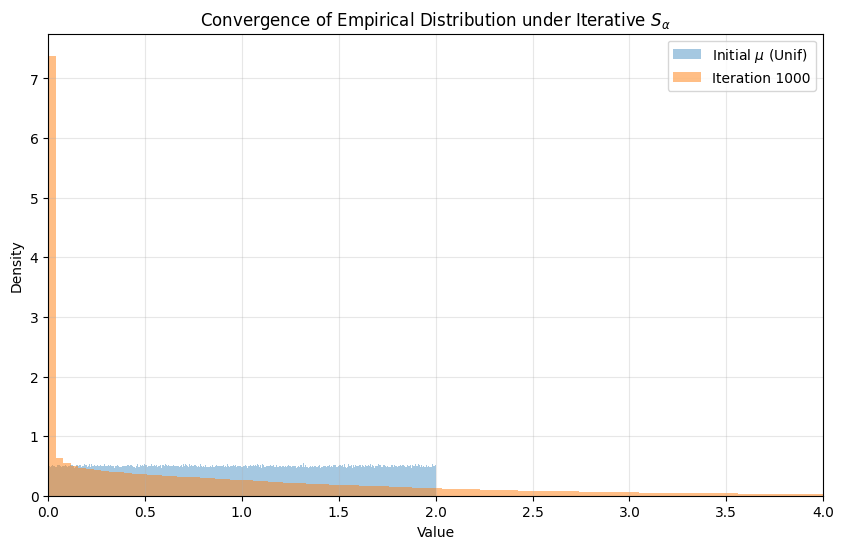

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def apply_operator(X, alpha=1.0, u=0.0, v=1.0):
    """
    Applies the S_alpha operator to a sample X representing the distribution \\mu.
    """
    N = len(X)
    
    # 1. Sample X^(1) and X^(2) i.i.d. from the current distribution X
    X1 = np.random.choice(X, size=N, replace=True)
    X2 = np.random.choice(X, size=N, replace=True)
    
    # 2. Sample U ~ Uniform(0, 1)
    U = np.random.uniform(0, 1, size=N)
    
    # 3. Sample I and J (Mutually exclusive Bernoulli variables)
    rand_vars = np.random.uniform(0, 1, size=N)
    I = (rand_vars < u).astype(float)
    J = ((rand_vars >= u) & (rand_vars < u + v)).astype(float)
    
    # 4. Calculate the unnormalized operator T_alpha(X)
    term1 = I * (U**alpha * X1 + (1 - U)**alpha * X2)
    term2 = J * np.maximum(U**alpha * X1, (1 - U)**alpha * X2)
    Y = term1 + term2
    
    # 5. Normalize to get S_alpha(X) = T_alpha(X) / E[T_alpha(X)]
    mean_Y = np.mean(Y)
    
    if mean_Y > 0:
        S = Y / mean_Y
    else:
        S = Y # Fallback to prevent division by zero if the population collapses
        
    return S

def run_simulation(N_samples=1000000, iterations=1000):
    # Initialize with a distribution \mu in M_s(1)
    # Using an Exponential(1) distribution as the starting point
    X_current = np.random.uniform(0.0, 2.0, size=N_samples)
    
    plt.figure(figsize=(10, 6))
    plt.hist(X_current, bins=1000, density=True, alpha=0.4, label='Initial $\\mu$ (Unif)')

    for i in range(iterations):
        X_current = apply_operator(X_current, alpha=1.0, u=0.5, v=0.3)
        
        # Plot intermediate and final distributions to observe convergence
        if i in [iterations - 1]:
            plt.hist(X_current, bins=1000, density=True, alpha=0.5, 
                     label=f'Iteration {i+1}')

    plt.title('Convergence of Empirical Distribution under Iterative $S_\\alpha$')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.xlim(0, 4)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    run_simulation()

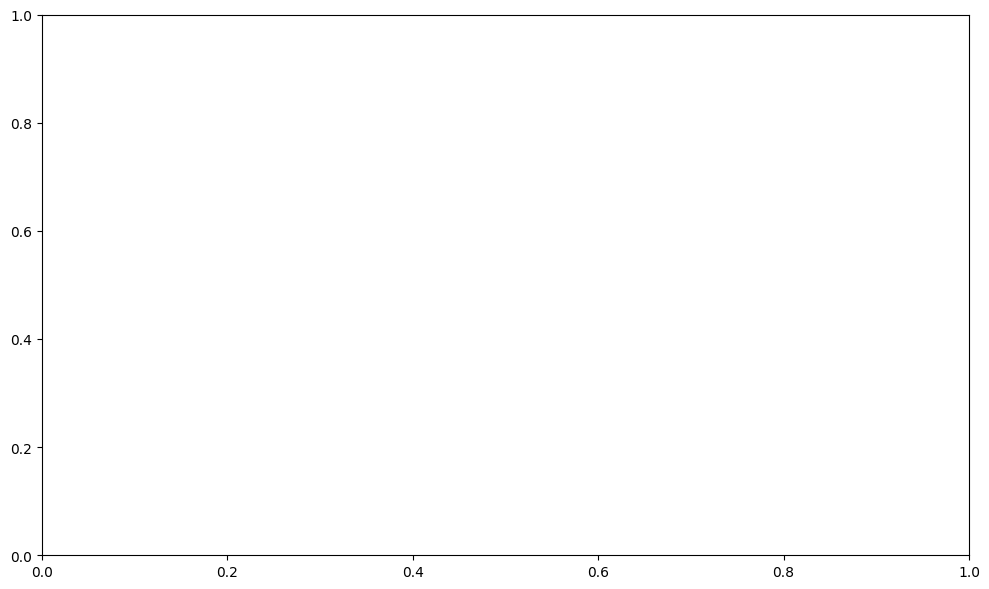

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# --- Parameters ---
ALPHA = 0.47
P_SUM = 0.50
N_PARTICLES = 5000
X_MAX = 5.0 # For plotting bounds

# --- 1. Initialize the Three Distributions ---
# Series 1: Dirac (All particles at exactly 1.0)
X_dirac = np.ones(N_PARTICLES)

# Series 2: Uniform (Spread evenly from 0 to 2)
X_unif = np.random.uniform(0.0, 2.0, N_PARTICLES)

# Series 3: Exponential (Mean of 1.0)
X_exp = np.random.exponential(1.0, N_PARTICLES)

# --- 2. The Operator S_alpha ---
def apply_S_alpha(X):
    """Applies the normalized operator S_alpha to a population X."""
    # Sample independent sub-trees
    X1 = np.random.choice(X, size=N_PARTICLES, replace=True)
    X2 = np.random.choice(X, size=N_PARTICLES, replace=True)
    
    # Generate splits and branch choices
    U = np.random.uniform(0, 1, N_PARTICLES)
    R = np.random.uniform(0, 1, N_PARTICLES)
    
    # Calculate weights
    term1 = (U**ALPHA) * X1
    term2 = ((1 - U)**ALPHA) * X2
    
    # Apply logic based on probability
    mask_sum = R < P_SUM
    mask_max = ~mask_sum
    
    Y = np.zeros(N_PARTICLES)
    Y[mask_sum] = term1[mask_sum] + term2[mask_sum]
    Y[mask_max] = np.maximum(term1[mask_max], term2[mask_max])
    
    # Normalize by the expected value (This turns T_alpha into S_alpha)
    return Y / np.mean(Y)

# --- 3. Visualization Setup ---
fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(0, X_MAX, 80)

def update(frame):
    global X_dirac, X_unif, X_exp
    ax.clear()
    
    # Plot the current histograms
    ax.hist(X_dirac, bins=bins, density=True, alpha=0.5, color='blue', label='Initial: Dirac')
    ax.hist(X_unif, bins=bins, density=True, alpha=0.5, color='orange', label='Initial: Uniform')
    ax.hist(X_exp, bins=bins, density=True, alpha=0.5, color='green', label='Initial: Exponential')
    
    # Formatting
    ax.set_title(f"Contraction to Fixed Point W* (Generation {frame})")
    ax.set_xlim(0, X_MAX)
    ax.set_ylim(0, 2.5) # Lock Y-axis to see the shape stabilize
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    
    # Apply the operator for the NEXT frame
    X_dirac = apply_S_alpha(X_dirac)
    X_unif = apply_S_alpha(X_unif)
    X_exp = apply_S_alpha(X_exp)

# --- 4. Run the Animation ---
# frames=30 means it will run 30 iterations. interval=400 is ms per frame.
ani = FuncAnimation(fig, update, frames=30, interval=400, repeat=False)

plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --- Parameters ---
ALPHA = 0.47
P_SUM = 0.50
N_PARTICLES = 50000
X_MAX = 5.0 

# --- 1. Initialize the Three Distributions ---
X_dirac = np.ones(N_PARTICLES)
X_unif = np.random.uniform(0.0, 2.0, N_PARTICLES)
X_exp = np.random.exponential(1.0, N_PARTICLES)

# --- 2. The Operator S_alpha ---
def apply_S_alpha(X):
    X1 = np.random.choice(X, size=N_PARTICLES, replace=True)
    X2 = np.random.choice(X, size=N_PARTICLES, replace=True)
    
    U = np.random.uniform(0, 1, N_PARTICLES)
    R = np.random.uniform(0, 1, N_PARTICLES)
    
    term1 = (U**ALPHA) * X1
    term2 = ((1 - U)**ALPHA) * X2
    
    mask_sum = R < P_SUM
    mask_max = ~mask_sum
    
    Y = np.zeros(N_PARTICLES)
    Y[mask_sum] = term1[mask_sum] + term2[mask_sum]
    Y[mask_max] = np.maximum(term1[mask_max], term2[mask_max])
    
    return Y / np.mean(Y)

# --- 3. Visualization Setup ---
fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(0, X_MAX, 80)

def update(frame):
    global X_dirac, X_unif, X_exp
    ax.clear()
    
    ax.hist(X_dirac, bins=bins, density=True, alpha=0.5, color='blue', label='Initial: Dirac')
    ax.hist(X_unif, bins=bins, density=True, alpha=0.5, color='orange', label='Initial: Uniform')
    ax.hist(X_exp, bins=bins, density=True, alpha=0.5, color='green', label='Initial: Exponential')
    
    ax.set_title(f"Contraction to Fixed Point W* (Generation {frame})")
    ax.set_xlim(0, X_MAX)
    ax.set_ylim(0, 2.5) 
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    
    X_dirac = apply_S_alpha(X_dirac)
    X_unif = apply_S_alpha(X_unif)
    X_exp = apply_S_alpha(X_exp)

# --- 4. Run the Animation in Jupyter ---
# Compile 40 frames (this might take 3-5 seconds to render in the cell)
ani = FuncAnimation(fig, update, frames=40, interval=200, repeat=False)

# Prevent the static duplicate plot from rendering above the animation
plt.close(fig) 

# Display the interactive HTML video player
HTML(ani.to_jshtml())

In [12]:
import numpy as np

# --- Parameters ---
ALPHA = 0.47
P_SUM = 0.50
N_PARTICLES = 10000000
S_ORDER = 1.5 # The order of the metric s in (1, 2]

def generate_initial_distributions():
    # Distribution X: Uniform
    X = np.random.uniform(0.0, 2.0, N_PARTICLES)
    
    # Distribution Y: Exponential
    Y = np.random.exponential(1.0, N_PARTICLES)
    
    # Force exact mean of 1.0 to establish the P_s(1) space
    return X / np.mean(X), Y / np.mean(Y)

def apply_S_alpha(X):
    X1 = np.random.choice(X, size=N_PARTICLES, replace=True)
    X2 = np.random.choice(X, size=N_PARTICLES, replace=True)
    
    U = np.random.uniform(0, 1, N_PARTICLES)
    R = np.random.uniform(0, 1, N_PARTICLES)
    
    term1 = (U**ALPHA) * X1
    term2 = ((1 - U)**ALPHA) * X2
    
    mask_sum = R < P_SUM
    mask_max = ~mask_sum
    
    Y = np.zeros(N_PARTICLES)
    Y[mask_sum] = term1[mask_sum] + term2[mask_sum]
    Y[mask_max] = np.maximum(term1[mask_max], term2[mask_max])
    
    # Normalize by the expected value
    return Y / np.mean(Y)

def wasserstein_s_distance(A, B, s):
    # 1D Wasserstein distance via sorted element-wise difference
    A_sorted = np.sort(A)
    B_sorted = np.sort(B)
    return np.mean(np.abs(A_sorted - B_sorted)**s)**(1/s)

# --- Run the Experiment ---
X, Y = generate_initial_distributions()

print(f"Empirical Contraction of S_alpha (alpha={ALPHA}, P_sum={P_SUM}, s={S_ORDER})")
print("-" * 75)
print(f"{'Generation':<15} | {'Distance W_s(X, Y)':<25} | {'Contraction Ratio':<20}")
print("-" * 75)

for i in range(1, 20):
    # 1. Calculate current distance
    current_dist = wasserstein_s_distance(X, Y, S_ORDER)
    
    # 2. Apply S_alpha to both populations
    X_next = apply_S_alpha(X)
    Y_next = apply_S_alpha(Y)
    
    # 3. Calculate new distance
    next_dist = wasserstein_s_distance(X_next, Y_next, S_ORDER)
    
    # 4. Calculate the ratio
    ratio = next_dist / current_dist
    
    print(f"Gen {i-1:02d} -> {i:02d}  | {current_dist:<25.6f} | {ratio:<20.6f}")
    
    # Update state for next generation
    X, Y = X_next, Y_next

Empirical Contraction of S_alpha (alpha=0.47, P_sum=0.5, s=1.5)
---------------------------------------------------------------------------
Generation      | Distance W_s(X, Y)        | Contraction Ratio   
---------------------------------------------------------------------------
Gen 00 -> 01  | 0.429762                  | 0.678359            
Gen 01 -> 02  | 0.291533                  | 0.688704            
Gen 02 -> 03  | 0.200780                  | 0.676951            
Gen 03 -> 04  | 0.135918                  | 0.661541            
Gen 04 -> 05  | 0.089915                  | 0.644913            
Gen 05 -> 06  | 0.057987                  | 0.630669            
Gen 06 -> 07  | 0.036571                  | 0.622707            
Gen 07 -> 08  | 0.022773                  | 0.612077            
Gen 08 -> 09  | 0.013939                  | 0.608722            
Gen 09 -> 10  | 0.008485                  | 0.590684            
Gen 10 -> 11  | 0.005012                  | 0.621173            
Ge